# Chapter 35: Future Directions — CCS and Hydrogen Integration

The oil and gas industry is evolving to integrate carbon capture and storage (CCS)
and hydrogen production into existing infrastructure. This chapter explores the
thermodynamic challenges of these emerging applications using NeqSim.

**Key learning objectives:**
- Model CO2-rich stream phase behavior for capture and transport
- Map the CO2 phase envelope and identify the dense phase transport region
- Analyze methane–hydrogen mixture properties for H2 blending
- Evaluate the effect of hydrogen blending on Wobbe index

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch24_future_directions.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 35.1 CO2 Capture — Phase Behavior of CO2-Rich Streams

Post-combustion capture produces a CO2-rich stream with impurities (N2, O2, Ar, H2O).
Understanding the phase behavior is critical for compression, dehydration, and transport
design. We model the properties at a range of pressures at 25 °C.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# CO2-rich stream with typical impurities
co2_fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 1.0)
co2_fluid.addComponent("CO2", 0.96)
co2_fluid.addComponent("nitrogen", 0.02)
co2_fluid.addComponent("oxygen", 0.01)
co2_fluid.addComponent("water", 0.01)
co2_fluid.setMixingRule("classic")

ops = jneqsim.thermodynamicoperations.ThermodynamicOperations(co2_fluid)

# Sweep pressure to map density and compressibility
pressures = np.arange(10, 210, 10)
densities = []
z_factors = []

for p in pressures:
    co2_fluid.setPressure(float(p))
    co2_fluid.setTemperature(273.15 + 25.0)
    ops.TPflash()
    co2_fluid.initProperties()
    assert _physics.state(co2_fluid, 'calculation_cell_3:co2_fluid', candidate=False)
    densities.append(co2_fluid.getDensity("kg/m3"))
    z_factors.append(co2_fluid.getZ())

print(f"{'P (bara)':>10} {'Density (kg/m3)':>16} {'Z-factor':>10}")
print("-" * 40)
for p, d, z in zip(pressures, densities, z_factors):
    print(f"{p:>10.0f} {d:>16.2f} {z:>10.4f}")


  P (bara)  Density (kg/m3)   Z-factor
----------------------------------------
        10            18.53     0.9440
        20            39.33     0.8911
        30            63.13     0.8342
        40            91.25     0.7711
        50           126.34     0.6981
        60           175.29     0.6060
        70           413.98     0.3047
        80           612.56     0.2387
        90           660.81     0.2498
       100           694.46     0.2648
       110           721.04     0.2811
       120           743.29     0.2979
       130           762.57     0.3150
       140           779.68     0.3322
       150           795.09     0.3494
       160           809.16     0.3666
       170           822.13     0.3837
       180           834.17     0.4008
       190           845.42     0.4178
       200           855.98     0.4347


## 35.2 CO2 Phase Envelope — Dense Phase Transport Region

For pipeline transport, CO2 is compressed above its critical point into the dense phase
region. We compute the phase envelope to identify the critical point and the operating
window for safe dense-phase transport.

SRK screening mixture: 96 mol% CO2, 2 mol% N2, 1 mol% O2, 1 mol% water. These are model predictions, not a certified transport envelope.


ch24_future_directions.ipynb:cell5:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


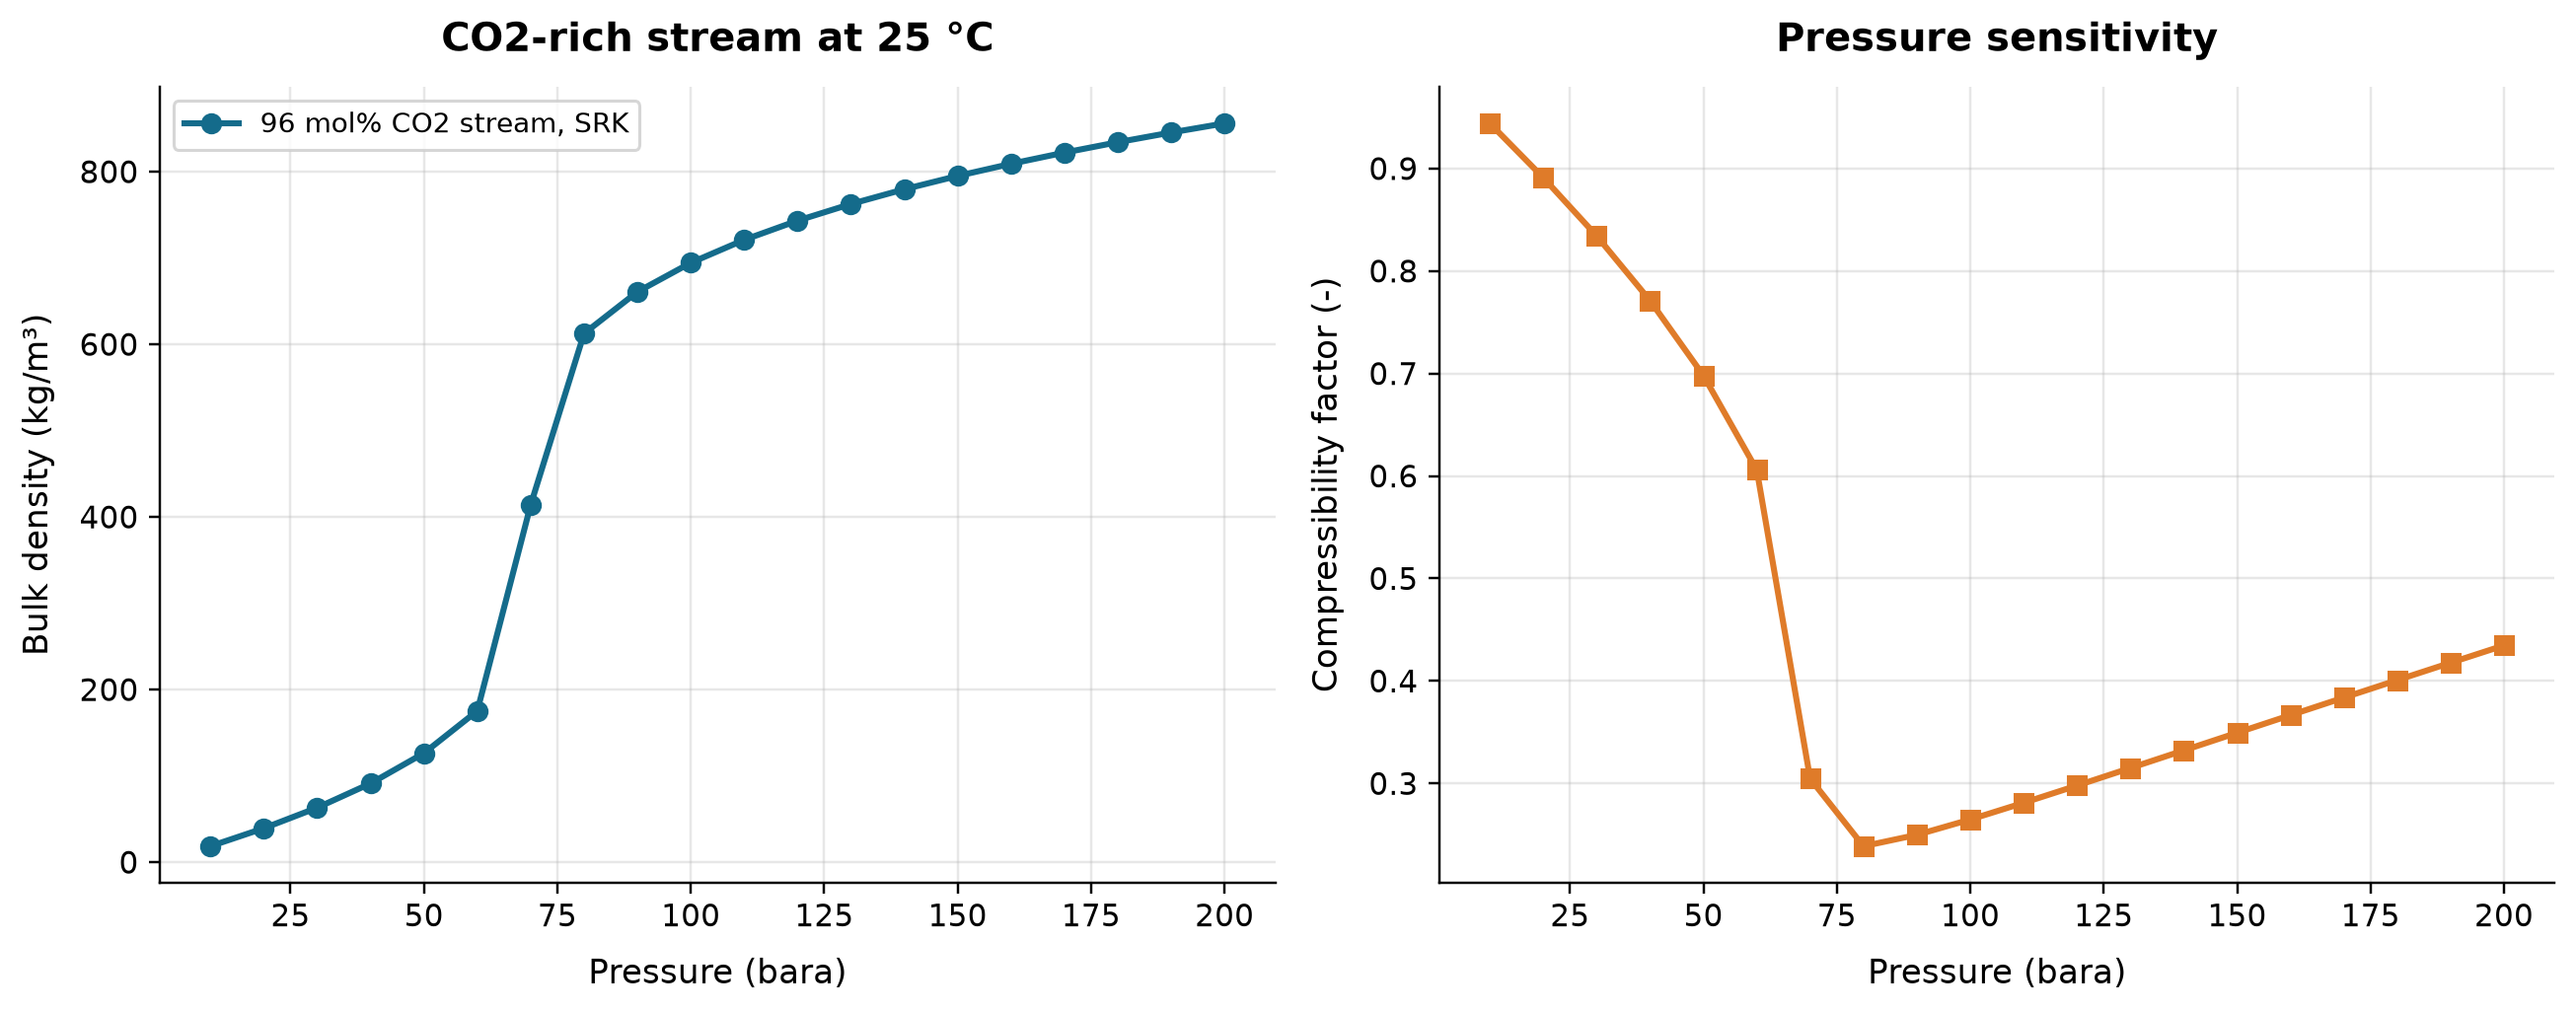

In [3]:
# Explicit density and compressibility calculations, not a phase-envelope fallback.
# Pure-CO2 critical properties do not define a mixture's two-phase boundary.
assert np.all(np.isfinite(densities)) and np.all(np.asarray(densities) > 0)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
ax.plot(pressures, densities, "o-", label="96 mol% CO2 stream, SRK")
ax.set(xlabel="Pressure (bara)", ylabel="Bulk density (kg/m³)", title="CO2-rich stream at 25 °C")
ax2.plot(pressures, z_factors, "s-", color="#DF7B29")
ax2.set(xlabel="Pressure (bara)", ylabel="Compressibility factor (-)", title="Pressure sensitivity")
for axis in (ax, ax2): axis.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ch35_co2_density_compressibility.png", dpi=220, bbox_inches="tight")
plt.show()
print("SRK screening mixture: 96 mol% CO2, 2 mol% N2, 1 mol% O2, 1 mol% water. These are model predictions, not a certified transport envelope.")


**Executed-figure discussion.** 96 mol% CO2 stream, SRK: bulk density spans 18.53–856 kg/m³ across the plotted cases. Compressibility factor spans 0.2387–0.944 across the plotted cases.

SRK predicts the bulk density and compressibility of the specified 96 mol percent CO2 mixture across pressure. These mixture properties do not by themselves define a safe transport envelope or establish reservoir miscibility. Validate the impurity-sensitive phase model and evaluate water, corrosion and transient constraints separately.


## 35.3 Hydrogen Blending — Mixture Properties

Blending hydrogen into natural gas pipelines is a near-term decarbonization strategy.
We model methane–hydrogen mixtures at varying H2 fractions to understand the impact
on density, heating value, and Wobbe index.

In [4]:
# Hydrogen blending study
h2_fractions = np.arange(0, 0.55, 0.05)  # 0% to 50% H2 by mole
wobbe_indices = []
densities_blend = []
molar_masses = []

for h2_frac in h2_fractions:
    ch4_frac = 1.0 - h2_frac
    blend = jneqsim.thermo.system.SystemSrkEos(273.15 + 15.0, 1.01325)
    blend.addComponent("methane", float(ch4_frac))
    blend.addComponent("hydrogen", float(h2_frac))
    blend.setMixingRule("classic")

    ops_blend = jneqsim.thermodynamicoperations.ThermodynamicOperations(blend)
    ops_blend.TPflash()
    blend.initProperties()
    assert _physics.state(blend, 'calculation_cell_7:blend', candidate=False)

    # Gas density at standard conditions
    rho_gas = blend.getDensity("kg/m3")
    densities_blend.append(rho_gas)

    # Molar mass
    mw = blend.getMolarMass() * 1000.0  # kg/mol to g/mol
    molar_masses.append(mw)

    # ISO 6976 calculation handles mole fractions consistently.
    # Volume and combustion reference temperatures are both 15 degrees C.
    gas_quality = jneqsim.standards.gasquality.Standard_ISO6976(blend, 15.0, 15.0, "volume")
    gas_quality.calculate()
    wobbe = float(gas_quality.getValue("SuperiorWobbeIndex")) / 1000.0  # kJ/m3 -> MJ/m3
    wobbe_indices.append(wobbe)

print(f"{'H2 (mol%)':>10} {'Density (kg/m3)':>16} {'MW (g/mol)':>12} {'Wobbe (MJ/m3)':>14}")
print("-" * 55)
for frac, d, mw, w in zip(h2_fractions, densities_blend, molar_masses, wobbe_indices):
    print(f"{frac*100:>10.0f} {d:>16.4f} {mw:>12.2f} {w:>14.2f}")
assert np.all(np.diff(wobbe_indices) < 0), "Hydrogen addition must reduce the superior Wobbe index for this methane blend"


 H2 (mol%)  Density (kg/m3)   MW (g/mol)  Wobbe (MJ/m3)
-------------------------------------------------------
         0           0.6799        16.04          50.73
         5           0.6500        15.34          50.11
        10           0.6202        14.64          49.49
        15           0.5903        13.94          48.86
        20           0.5605        13.24          48.24
        25           0.5307        12.54          47.62
        30           0.5010        11.83          47.00
        35           0.4712        11.13          46.39
        40           0.4414        10.43          45.79
        45           0.4117         9.73          45.20
        50           0.3820         9.03          44.63


Figure saved: ../figures/ch24_h2_blending_wobbe.png


ch24_future_directions.ipynb:cell8:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


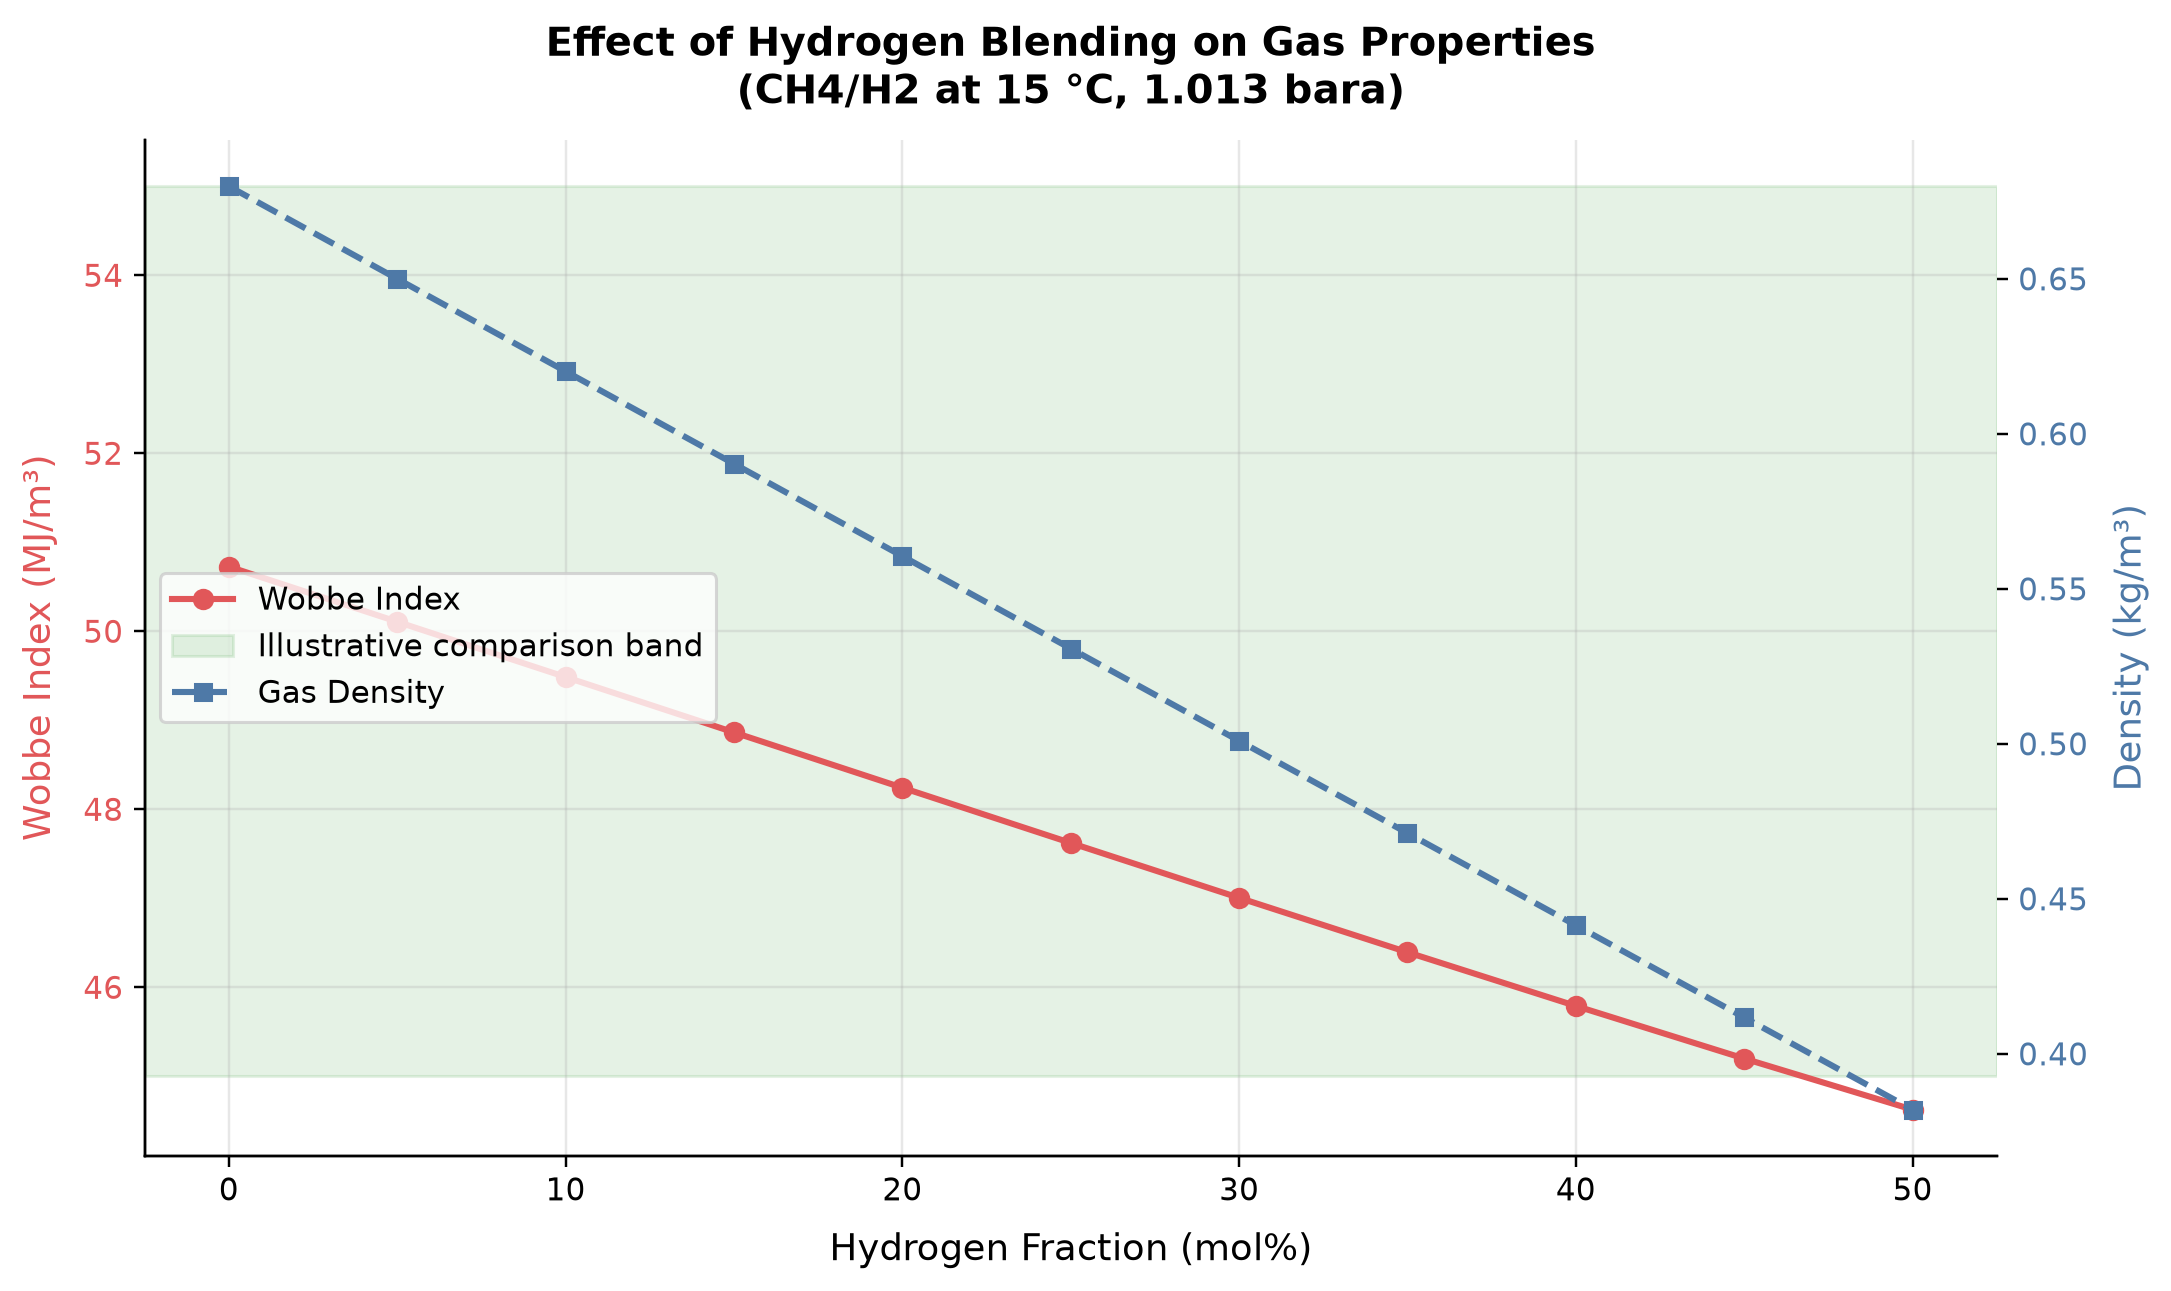

In [5]:
# Plot Wobbe index vs H2 fraction
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "#e15759"
ax1.plot(h2_fractions * 100, wobbe_indices, "o-", color=color1, linewidth=2,
         markersize=6, label="Wobbe Index")
ax1.set_xlabel("Hydrogen Fraction (mol%)", fontsize=12)
ax1.set_ylabel("Wobbe Index (MJ/m³)", fontsize=12, color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

# Example comparison band only; appliance interchangeability needs a full specification.
ax1.axhspan(45, 55, alpha=0.1, color="green", label="Illustrative comparison band")

# Secondary axis: density
ax2 = ax1.twinx()
color2 = "#4e79a7"
ax2.plot(h2_fractions * 100, densities_blend, "s--", color=color2, linewidth=2,
         markersize=5, label="Gas Density")
ax2.set_ylabel("Density (kg/m³)", fontsize=12, color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=10)

ax1.set_title("Effect of Hydrogen Blending on Gas Properties\n(CH4/H2 at 15 °C, 1.013 bara)",
              fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch24_h2_blending_wobbe.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch24_h2_blending_wobbe.png")


**Executed-figure discussion.** From 0 to 50 mol% hydrogen in methane, the calculated superior Wobbe index decreases from 50.73 to 44.63 MJ/m³. The standard-condition density decreases from 0.680 to 0.382 kg/m³.

ISO 6976 combines blend calorific value and relative density using consistent 15 degree Celsius reference conditions. Hydrogen enrichment lowers this blend’s Wobbe index, but Wobbe alone does not establish appliance interchangeability. Check the complete gas-quality and end-use specification at the selected hydrogen fraction.


## 35.4 Discussion and Outlook

**CO2 transport:** The phase envelope shows that the CO2-rich stream (with impurities)
has a cricondenbar slightly above the pure CO2 critical pressure (73.8 bara). For safe
dense-phase pipeline transport, operating above ~100 bara and 10–40 °C avoids two-phase
flow. Impurities (especially N2) raise the saturation pressure, requiring higher
minimum operating pressures.

**Hydrogen blending:** Increasing H2 fraction from 0% to 50% significantly reduces
gas density and Wobbe index. Most gas appliances require a Wobbe index within ±5% of
design value, suggesting a practical blending limit of 10–20 mol% H2 without
appliance modification. Higher H2 fractions would require burner redesign.

**Future integration opportunities:**
- Coupling CCS with offshore platform exhaust gas treatment
- Blue hydrogen production from natural gas with CCS
- Green hydrogen from offshore wind-powered electrolysis
- Dynamic modeling of intermittent hydrogen injection into gas networks

## Summary

This chapter demonstrated NeqSim's capabilities for modeling future energy systems:

- **CO2 phase behavior** — density transition from gas to dense phase above the
  critical point, essential for compression and pipeline design
- **Phase envelope mapping** — identifying safe operating windows for CO2 transport
- **Hydrogen blending** — quantifying the impact on Wobbe index and gas density
  as H2 fraction increases from 0% to 50%

These thermodynamic tools enable engineers to design and evaluate CCS infrastructure
and hydrogen integration strategies using rigorous equation-of-state models.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [6]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                              Figure  Panel                  Series              Output / unit  Minimum  Maximum  Finite points  Missing points
ch35_co2_density_compressibility.png      1 96 mol% CO2 stream, SRK       Bulk density (kg/m³)  18.5327  855.981             20               0
ch35_co2_density_compressibility.png      2                 Curve 1 Compressibility factor (-) 0.238749 0.944037             20               0
          ch24_h2_blending_wobbe.png      1             Wobbe Index        Wobbe Index (MJ/m³)  44.6251  50.7265             11               0
          ch24_h2_blending_wobbe.png      2             Gas Density            Density (kg/m³) 0.381988 0.679856             11               0


## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [7]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 48 distinct checks, 574 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

CO2 PVT domains and hydrogen-mixture calorific trends. Single-phase CO2 is not miscibility evidence; H2 Wobbe trends do not establish material compatibility or burner interchangeability.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
